# A06 — Two-Qubit Gates and Controlled Operations

**Track A — under the hood.** Pure NumPy. Qiskit is not imported anywhere in this
notebook; every matrix here is one you can write down by hand.

---

## The one-sentence version

A two-qubit gate is a $4\times4$ unitary — and the interesting ones are the
**controlled** gates, which say *"look at one qubit; if it is 1, do something to
the other."*

That "if" is where everything changes. Up to now (A03, A04) every gate acted on
one qubit at a time, and a register of $n$ qubits was really just $n$ separate
little stories. A controlled gate **ties two qubits together**. It is the *only*
way to create entanglement — and the last figure in this notebook proves that no
pile of single-qubit gates, however clever, can ever do it.

## Why "controlled" is a lie you should stop believing early

The word *control* suggests a wire and a direction: qubit A pushes qubit B
around, and B doesn't push back. That intuition is wrong, and this notebook
kills it twice.

- **CZ is symmetric.** Swap which qubit you call the control and the matrix does
  not change at all. There is no arrow.
- **CNOT's direction is basis-dependent.** A CNOT that flips $|0\rangle/|1\rangle$
  on the target flips $|+\rangle/|-\rangle$ on the *control* — the famous phase
  kickback that A10 turns into an algorithm.

"Control" is a name we give to a particular block structure in a particular
basis. It is real, it is useful, and it is not a causal arrow.

## What we build here

1. CNOT, CZ, SWAP, iSWAP, CRz as explicit matrices, and their block structure.
2. A generic `controlled(U, control, target)` built from projectors:
   $|0\rangle\langle0|\otimes I + |1\rangle\langle1|\otimes U$ — with the
   endianness handled properly, which is where the bugs live.
3. Permutation graphs, which make CNOT / SWAP / Toffoli click instantly.
4. Three identities worth knowing: $\mathrm{CNOT} = (I\otimes H)\,\mathrm{CZ}\,(I\otimes H)$,
   CZ's control/target symmetry, and $\mathrm{SWAP} = 3\ \mathrm{CNOTs}$.
5. The entanglement proof: a rank test that a two-qubit gate can change and a
   single-qubit gate provably cannot.

In [1]:
from qviz import backends, grid, style

import matplotlib.pyplot as plt
import numpy as np

style.use()

SEED = backends.seed_for("A06")
rng = np.random.default_rng(SEED)
print("seed:", SEED)

seed: 20260810


## First: which qubit is which

This is the single most common source of silent bugs in two-qubit code, so we
pin it down before writing a gate.

**The repo convention (little-endian, matching Qiskit).** A basis state of an
$n$-qubit register is labelled by a bitstring in which **qubit 0 is the rightmost
character**. So for two qubits the four labels are

| index | label | qubit 1 | qubit 0 |
|---|---|---|---|
| 0 | `00` | 0 | 0 |
| 1 | `01` | 0 | **1** |
| 2 | `10` | **1** | 0 |
| 3 | `11` | **1** | **1** |

Index $i$ has qubit $q$'s bit equal to `(i >> q) & 1`. Read that line twice; it
is the whole convention.

**What that does to the Kronecker product.** To place an operator $U$ on qubit
$k$ we build

$$\underbrace{I\otimes\cdots\otimes I}_{\text{qubits } n-1 \ldots k+1}\ \otimes\ U\ \otimes\ \underbrace{I\otimes\cdots\otimes I}_{\text{qubits } k-1 \ldots 0},$$

i.e. the factors run from the **highest** qubit index down to qubit 0. The
textbook `np.kron(q0, q1)` ordering is the opposite and would put qubit 0 on the
left, which silently disagrees with every Track B result. A05 spends a whole
section on this; here we just use it.

`op_on` below is the same helper A05 defines, with the same convention, so the
two notebooks agree.

In [2]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
S = np.diag([1, 1j]).astype(complex)
T = np.diag([1, np.exp(1j * np.pi / 4)]).astype(complex)

P0 = np.array([[1, 0], [0, 0]], dtype=complex)      # |0><0|
P1 = np.array([[0, 0], [0, 1]], dtype=complex)      # |1><1|


def op_on(U, k, n):
    """Place the single-qubit operator U on qubit k of an n-qubit register.

    Little-endian: qubit 0 is the RIGHTMOST label character, so it is the LAST
    factor in the Kronecker product. The loop therefore runs n-1 down to 0.
    """
    out = np.array([[1.0 + 0j]])
    for j in range(n - 1, -1, -1):
        out = np.kron(out, U if j == k else I2)
    return out


def bits_of(i, n):
    """bits_of(i, n)[q] is qubit q's value in basis state i."""
    return [(i >> q) & 1 for q in range(n)]


def index_of(bits):
    """Inverse of bits_of."""
    return sum(b << q for q, b in enumerate(bits))


def label(i, n):
    """The printed bitstring: qubit n-1 leftmost, qubit 0 rightmost."""
    return format(i, f"0{n}b")


for i in range(4):
    b = bits_of(i, 2)
    print(f"index {i}  label |{label(i, 2)}>   qubit0={b[0]}  qubit1={b[1]}")

# X on qubit 0 of |00> must land on index 1, printed |01>.
v = np.zeros(4, dtype=complex); v[0] = 1
out = op_on(X, 0, 2) @ v
print("\nX on qubit 0 of |00> -> index", int(np.argmax(np.abs(out))),
      "=", "|" + label(int(np.argmax(np.abs(out))), 2) + ">")

index 0  label |00>   qubit0=0  qubit1=0
index 1  label |01>   qubit0=1  qubit1=0
index 2  label |10>   qubit0=0  qubit1=1
index 3  label |11>   qubit0=1  qubit1=1

X on qubit 0 of |00> -> index 1 = |01>


## CNOT, three ways

We will build CNOT three separate ways and check they agree. Redundancy is the
point: if the projector construction and the hand-written truth table disagree,
one of them has an endianness bug, and we want to find out here rather than in
A10.

**Way 1 — the definition, in words.** If the control qubit is 1, flip the target;
otherwise do nothing.

**Way 2 — the projector form.**

$$\mathrm{CU} = |0\rangle\langle0|_c \otimes I + |1\rangle\langle1|_c \otimes U_t$$

read as: the projector onto "control is 0" times identity, plus the projector
onto "control is 1" times $U$ on the target. Written with `op_on` this is
endianness-safe for *any* pair of qubits in *any* size register, which is why we
write it this way rather than typing out a $4\times4$ array.

**Way 3 — the literal matrix**, typed out by hand from the truth table.

In [3]:
def controlled(U, control, target, n=2):
    """Controlled-U: |0><0|_c (x) I  +  |1><1|_c (x) U_t.

    The two terms commute because they act on different qubits, so the second
    term can be written as a plain matrix product of the projector and U_t.
    """
    if control == target:
        raise ValueError("control and target must be different qubits")
    return op_on(P0, control, n) + op_on(P1, control, n) @ op_on(U, target, n)


def permutation_matrix(rule, n):
    """Build a matrix from a classical bit rule: bits -> bits."""
    dim = 2 ** n
    M = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        M[index_of(rule(bits_of(i, n))), i] = 1.0   # column i -> row f(i)
    return M


def cnot_truth_table(control, target, n=2):
    """CNOT written straight from the classical truth table."""
    def rule(b):
        b = list(b)
        if b[control] == 1:
            b[target] ^= 1
        return b
    return permutation_matrix(rule, n)


CNOT_10 = controlled(X, control=1, target=0)     # control q1, target q0
CNOT_01 = controlled(X, control=0, target=1)     # control q0, target q1

# Way 3: typed out by hand. Rows/cols are ordered |00>, |01>, |10>, |11>.
CNOT_10_HAND = np.array([[1, 0, 0, 0],
                         [0, 1, 0, 0],
                         [0, 0, 0, 1],
                         [0, 0, 1, 0]], dtype=complex)
CNOT_01_HAND = np.array([[1, 0, 0, 0],
                         [0, 0, 0, 1],
                         [0, 0, 1, 0],
                         [0, 1, 0, 0]], dtype=complex)

print("projector form == truth table  :",
      np.allclose(CNOT_10, cnot_truth_table(1, 0)),
      np.allclose(CNOT_01, cnot_truth_table(0, 1)))
print("projector form == hand-typed   :",
      np.allclose(CNOT_10, CNOT_10_HAND),
      np.allclose(CNOT_01, CNOT_01_HAND))

print("\ncontrol q1 -> target q0        control q0 -> target q1")
for i in range(4):
    j10 = int(np.argmax(np.abs(CNOT_10[:, i])))
    j01 = int(np.argmax(np.abs(CNOT_01[:, i])))
    print(f"  |{label(i,2)}> -> |{label(j10,2)}>"
          f"                    |{label(i,2)}> -> |{label(j01,2)}>")

projector form == truth table  : True True
projector form == hand-typed   : True True

control q1 -> target q0        control q0 -> target q1
  |00> -> |00>                    |00> -> |00>
  |01> -> |01>                    |01> -> |11>
  |10> -> |11>                    |10> -> |10>
  |11> -> |10>                    |11> -> |01>


Look at what just happened, because it is the whole endianness lesson in one
picture.

**CNOT with control = qubit 1** comes out as the familiar textbook block matrix

$$\begin{pmatrix} I & 0 \\ 0 & X\end{pmatrix},$$

a clean $2\times2$ identity block in the top-left and an $X$ block in the
bottom-right. That is because qubit 1 is the *leftmost* label character, so
sorting basis states by index also sorts them by "control off / control on".

**CNOT with control = qubit 0** is the *same gate with the roles exchanged*, but
its matrix looks scrambled: it swaps indices 1 and 3, which are not adjacent. The
"blocks" are still there — they are just **interleaved**, on the odd rows and odd
columns.

Neither matrix is more correct. But if you have ever copy-pasted a CNOT from a
textbook into Qiskit-compatible code and got the wrong answer, this is why.

## Figure 1 — the zoo, as block structure

Six two-qubit gates. Each cell is coloured by the **phase** of that matrix entry;
zero entries are left blank grey. Every non-zero entry of every gate here has
magnitude 1, so hue alone carries the full information: blue is $+1$, the
opposite hue is $-1$, quarter-turns are $\pm i$.

The heavy black box marks the **active block** — the rows and columns the gate
actually touches. Everything outside it is the identity. Read the six panels as
"how much of the space does this gate disturb, and where?"

We plot phase rather than the real part on purpose: iSWAP and CRz have entries
that are purely imaginary or complex, and a real-part heatmap would draw those
cells as *blank*, which is a lie about the gate.

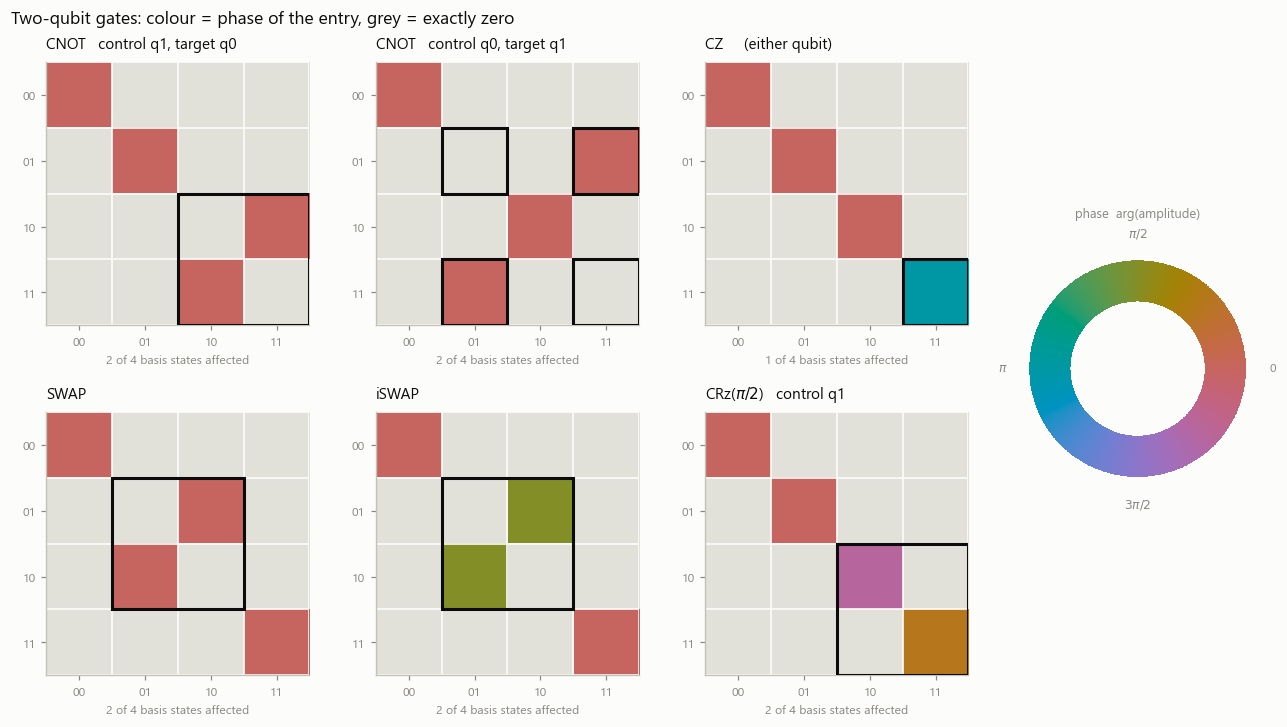

In [4]:
from matplotlib.patches import Rectangle


def _runs(idx):
    """Group sorted indices into contiguous runs, so a block gets one box."""
    idx = sorted(idx)
    out, s, p = [], idx[0], idx[0]
    for v in idx[1:]:
        if v == p + 1:
            p = v
        else:
            out.append((s, p))
            s = p = v
    out.append((s, p))
    return out


def outline(ax, rows, cols, color=style.INK, lw=2.0, ls="-"):
    """Box the sub-block on these rows/cols (one box per contiguous run)."""
    for r0, r1 in _runs(rows):
        for c0, c1 in _runs(cols):
            ax.add_patch(Rectangle((c0 - 0.5, r0 - 0.5), c1 - c0 + 1,
                                   r1 - r0 + 1, fill=False, edgecolor=color,
                                   lw=lw, ls=ls, zorder=6))


def crz(theta, control, target, n=2):
    return controlled(np.diag([np.exp(-1j * theta / 2),
                               np.exp(1j * theta / 2)]), control, target, n)


CZ = controlled(Z, control=1, target=0)
CZ_REV = controlled(Z, control=0, target=1)
SWAP = permutation_matrix(lambda b: [b[1], b[0]], 2)
ISWAP = np.array([[1, 0, 0, 0],
                  [0, 0, 1j, 0],
                  [0, 1j, 0, 0],
                  [0, 0, 0, 1]], dtype=complex)
CRZ = crz(np.pi / 2, control=1, target=0)

panels = [
    ("CNOT   control q1, target q0", CNOT_10, [2, 3]),
    ("CNOT   control q0, target q1", CNOT_01, [1, 3]),
    ("CZ     (either qubit)", CZ, [3]),
    ("SWAP", SWAP, [1, 2]),
    ("iSWAP", ISWAP, [1, 2]),
    (r"CRz($\pi/2$)   control q1", CRZ, [2, 3]),
]

fig = plt.figure(figsize=(11.6, 6.5))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.75])
for k, (name, M, active) in enumerate(panels):
    ax = fig.add_subplot(gs[k // 3, k % 3])
    grid.matrix(ax, M, part="phase", cbar=False, annot=False, title=name)
    outline(ax, active, active)
    n_move = int(np.sum(~np.isclose(np.diag(M), 1.0)))
    ax.set_xlabel(f"{n_move} of 4 basis states affected", fontsize=8,
                  color=style.MUTED)

axw = fig.add_subplot(gs[:, 3], projection="polar")
style.phase_wheel(axw)
fig.suptitle("Two-qubit gates: colour = phase of the entry, grey = exactly zero",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

Things worth noticing:

- **CZ is a single cell.** Out of sixteen matrix entries, one is different from
  the identity: the $|11\rangle$ diagonal flips sign. That is the entire gate.
  And notice its active block is on the **diagonal** — CZ never moves amplitude
  between basis states, it only re-signs one of them. This is why the next figure
  can show CZ changing nothing measurable and still mattering enormously.
- **CNOT and SWAP are permutation matrices**: exactly one 1 per row and column,
  no phases. They shuffle basis states around, nothing else.
- **iSWAP is SWAP with teeth.** Same permutation, but each swapped amplitude
  picks up a factor of $i$. On hardware this is often the *native* gate — the
  physical interaction gives you iSWAP and CNOT is the thing you have to
  synthesise, not the other way round.
- **CRz is diagonal**, like CZ, and in fact $\mathrm{CZ}$ is $\mathrm{CRz}(\pi)$
  up to a single-qubit phase. Diagonal two-qubit gates are the cheap ones: they
  commute with each other, which is exactly what makes the QAOA cost layer in C29
  tractable.
- Compare panels 1 and 2 again. Same gate, roles exchanged, and the black box
  goes from one contiguous square to four scattered cells. **The block structure
  is a property of the labelling, not of the physics.**

## Figure 2 — Toffoli: a three-qubit gate that is 75% identity

The Toffoli gate (CCX) flips the target only when **both** controls are 1. It is
universal for classical reversible computation — AND, NAND, and fan-out all fall
out of it — and it is the workhorse of every arithmetic circuit in this repo.

Its matrix is $8\times8$. Sixty-four entries. And here is the thing worth seeing:
**sixty-two of them are the identity's**. The whole gate is one $2\times2$ swap
hiding in the corner.

Both panels below are the same gate up to relabelling. The left one puts the
controls on qubits 1 and 2 (the two *leftmost* label characters), which makes the
active block land contiguously in the bottom-right corner — the picture you have
seen in textbooks. The right one puts the controls on qubits 0 and 1, and the
same $2\times2$ block scatters to rows/columns $\{3, 7\}$.

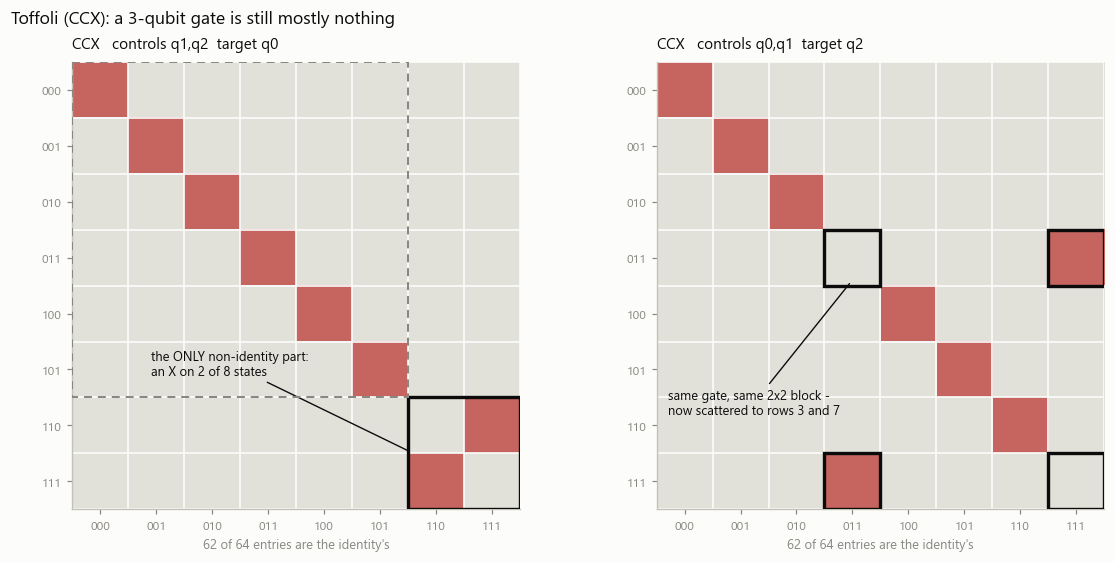

non-identity entries in CCX: 4 of 64


In [5]:
def multi_controlled(U, controls, target, n):
    """U on `target`, applied only when every qubit in `controls` reads 1."""
    dim = 2 ** n
    proj = np.eye(dim, dtype=complex)
    for c in controls:
        proj = proj @ op_on(P1, c, n)          # projector onto "all controls 1"
    return np.eye(dim, dtype=complex) - proj + proj @ op_on(U, target, n)


def ccx_truth_table(controls, target, n=3):
    def rule(b):
        b = list(b)
        if all(b[c] == 1 for c in controls):
            b[target] ^= 1
        return b
    return permutation_matrix(rule, n)


CCX_12_0 = multi_controlled(X, controls=(1, 2), target=0, n=3)
CCX_01_2 = multi_controlled(X, controls=(0, 1), target=2, n=3)

assert np.allclose(CCX_12_0, ccx_truth_table((1, 2), 0))
assert np.allclose(CCX_01_2, ccx_truth_table((0, 1), 2))

fig, axes = plt.subplots(1, 2, figsize=(10.6, 5.0))
for ax, (name, M, active) in zip(axes, [
        ("CCX   controls q1,q2  target q0", CCX_12_0, [6, 7]),
        ("CCX   controls q0,q1  target q2", CCX_01_2, [3, 7])]):
    grid.matrix(ax, M, part="phase", cbar=False, annot=False, title=name)
    outline(ax, active, active, color=style.INK, lw=2.2)

# The untouched part is contiguous only in the left panel; box it there.
outline(axes[0], list(range(6)), list(range(6)), color=style.MUTED, lw=1.3,
        ls=(0, (4, 3)))

grid.annotate(axes[0], "the ONLY non-identity part:\nan X on 2 of 8 states",
              xy=(5.6, 6.5), xytext=(0.9, 4.9), color=style.INK)
grid.annotate(axes[1], "same gate, same 2x2 block -\nnow scattered to rows 3 and 7",
              xy=(3.0, 3.4), xytext=(-0.3, 5.6), color=style.INK)
for ax in axes:
    ax.set_xlabel("62 of 64 entries are the identity's", fontsize=8.5,
                  color=style.MUTED)
fig.suptitle("Toffoli (CCX): a 3-qubit gate is still mostly nothing",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("non-identity entries in CCX:",
      int(np.sum(~np.isclose(CCX_12_0, np.eye(8)))), "of 64")

The dashed grey box is the part of the gate that does nothing at all. It gets
worse (better?) with size: an $n$-controlled-X on $n+1$ qubits is a $2^{n+1}$
matrix in which exactly **two** entries differ from the identity. The matrix
representation spends essentially all of its memory storing "nothing happens
here", which is the first hint that forming these matrices is the wrong way to
simulate. A07 acts on the statevector directly and never builds them.

## Figure 3 — the permutation view

Here is the picture that makes these gates click, and it is not a matrix.

CNOT, SWAP and Toffoli are **permutation matrices**: they take each basis state
to exactly one other basis state, with coefficient 1. So draw the basis states as
nodes and the gate as arrows. A double-headed arrow means the two states trade
places; a hollow node means the state is left exactly where it was.

Read a matrix and you have to trace a column to a row. Read this and you see the
gate in one glance.

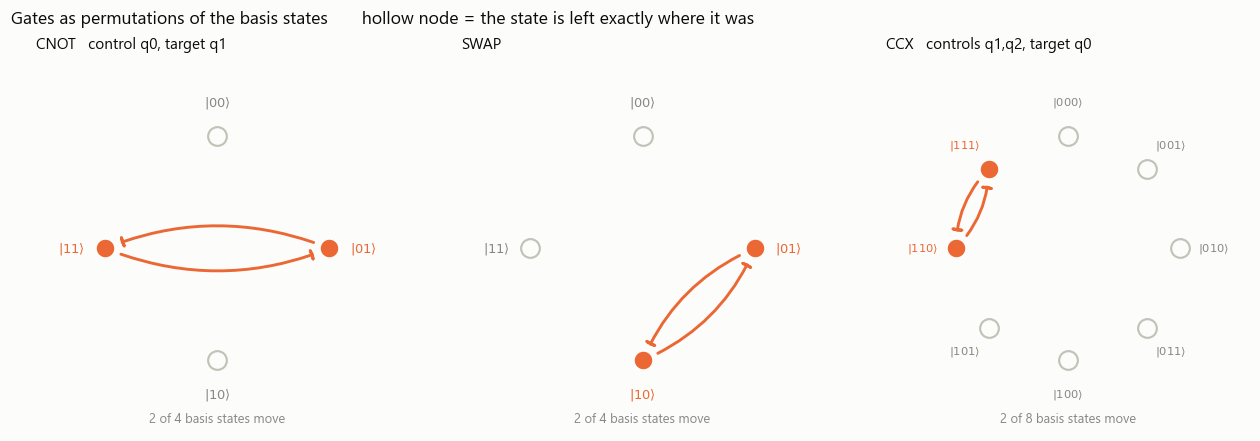

    CNOT c=q0,t=q1:  |01> -> |11>, |11> -> |01>
              SWAP:  |01> -> |10>, |10> -> |01>
  CCX c=q1,q2,t=q0:  |110> -> |111>, |111> -> |110>


In [6]:
from matplotlib.patches import FancyArrowPatch


def permutation_of(M):
    """For a permutation matrix, perm[i] = index that basis state i lands on."""
    return [int(np.argmax(np.abs(M[:, i]))) for i in range(M.shape[0])]


def perm_graph(ax, M, n_qubits, title=None, label_radius=1.30):
    """Basis states as nodes on a circle; the gate's action as arrows."""
    perm = permutation_of(M)
    d = len(perm)
    ang = np.pi / 2 - 2 * np.pi * np.arange(d) / d     # index 0 at the top, cw
    xs, ys = np.cos(ang), np.sin(ang)
    moved = [i for i in range(d) if perm[i] != i]

    for i in moved:
        j = perm[i]
        if i < j:
            ax.add_patch(FancyArrowPatch(
                (xs[i], ys[i]), (xs[j], ys[j]),
                connectionstyle="arc3,rad=0.20", arrowstyle="-|>,head_width=3",
                shrinkA=11, shrinkB=11, lw=1.9, color=style.ORANGE, zorder=2))
            ax.add_patch(FancyArrowPatch(
                (xs[j], ys[j]), (xs[i], ys[i]),
                connectionstyle="arc3,rad=0.20", arrowstyle="-|>,head_width=3",
                shrinkA=11, shrinkB=11, lw=1.9, color=style.ORANGE, zorder=2))

    fixed = [i for i in range(d) if perm[i] == i]
    ax.scatter(xs[fixed], ys[fixed], s=150, facecolor=style.SURFACE,
               edgecolor=style.AXIS, linewidths=1.4, zorder=3)
    ax.scatter(xs[moved], ys[moved], s=165, facecolor=style.ORANGE,
               edgecolor=style.SURFACE, linewidths=1.4, zorder=3)

    for i in range(d):
        col = style.ORANGE if perm[i] != i else style.MUTED
        ax.text(xs[i] * label_radius, ys[i] * label_radius,
                grid.ket(label(i, n_qubits)), ha="center", va="center",
                fontsize=8.5 if d <= 4 else 7.5, color=col, zorder=4)

    ax.set_xlim(-1.62, 1.62)
    ax.set_ylim(-1.62, 1.62)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, loc="left", fontsize=10, color=style.INK, pad=12)
    ax.text(0.0, -1.58, f"{len(moved)} of {d} basis states move",
            ha="center", va="bottom", fontsize=8.5, color=style.MUTED)
    return perm


fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.9))
perm_graph(axes[0], CNOT_01, 2, "CNOT   control q0, target q1")
perm_graph(axes[1], SWAP, 2, "SWAP")
perm_graph(axes[2], CCX_12_0, 3, "CCX   controls q1,q2, target q0")
fig.suptitle("Gates as permutations of the basis states       "
             "hollow node = the state is left exactly where it was",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

for name, M, n in [("CNOT c=q0,t=q1", CNOT_01, 2), ("SWAP", SWAP, 2),
                   ("CCX c=q1,q2,t=q0", CCX_12_0, 3)]:
    p = permutation_of(M)
    print(f"{name:>18}:  " + ", ".join(f"|{label(i,n)}> -> |{label(p[i],n)}>"
                                       for i in range(len(p)) if p[i] != i))

Three readings, all instant:

- **CNOT** (control qubit 0) swaps $|01\rangle \leftrightarrow |11\rangle$ — the
  two states where qubit 0 is 1 — and leaves the other two alone. "If the control
  is on, flip the other bit" is now something you can *see*.
- **SWAP** exchanges $|01\rangle \leftrightarrow |10\rangle$ and fixes the two
  states where both qubits agree. Obvious in hindsight: if both qubits are the
  same, swapping them does nothing.
- **Toffoli** touches one adjacent pair out of eight nodes. Six hollow nodes is
  the picture of a gate that almost never fires.

A caution, and it is an important one: **this picture only works for permutation
gates.** CZ, CRz and iSWAP are not permutations of basis states — CZ moves no
amplitude at all — so they have no arrows to draw. The next figure is what CZ
looks like instead.

## Figure 4 — CZ on $|{+}{+}\rangle$: nothing happens, and everything happens

Take both qubits to $|+\rangle$, so all four amplitudes are $\tfrac12$, and apply
CZ.

$$\mathrm{CZ}\,|{+}{+}\rangle = \tfrac12\big(|00\rangle + |01\rangle + |10\rangle - |11\rangle\big).$$

Exactly one bar flips its phase by $\pi$. The **magnitudes do not change**, so
neither do the probabilities: measure this state and you get the same uniform
$25\%$ you got before, forever, no matter how many shots you take.

So did anything happen? Yes — the state after is **entangled** and the state
before is not, and there is a measurement (in the $|{\pm}\rangle$ basis) that
tells them apart cold. But the measurement we happen to be doing here is blind to
it. This is the setup A08 pays off: a phase you cannot see becomes an answer you
can, as soon as you interfere it with something.

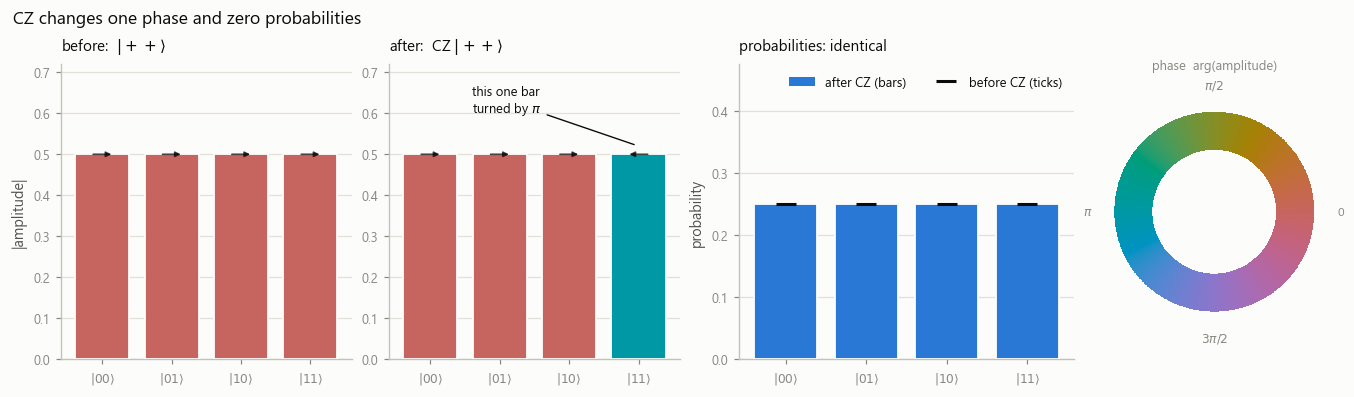

magnitudes before: [0.5 0.5 0.5 0.5]
magnitudes after : [0.5 0.5 0.5 0.5]
probabilities equal?  True
states equal?         False


In [7]:
PLUSPLUS = np.full(4, 0.5, dtype=complex)          # |+> (x) |+>
after_cz = CZ @ PLUSPLUS

fig = plt.figure(figsize=(12.2, 3.5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.15, 0.72])

ax0 = fig.add_subplot(gs[0, 0])
grid.amp_bars(ax0, PLUSPLUS, ylim=0.72)
ax0.set_title("before:  " + grid.ket("++"), loc="left", fontsize=10)

ax1 = fig.add_subplot(gs[0, 1])
grid.amp_bars(ax1, after_cz, ylim=0.72)
ax1.set_title("after:  CZ " + grid.ket("++"), loc="left", fontsize=10)
ax1.set_ylabel("")
grid.annotate(ax1, "this one bar\nturned by $\\pi$", xy=(3.0, 0.52),
              xytext=(0.6, 0.63), color=style.INK)

ax2 = fig.add_subplot(gs[0, 2])
grid.prob_bars(ax2, np.abs(after_cz) ** 2, analytic=np.abs(PLUSPLUS) ** 2,
               ymax_pad=1.9)
# Build the legend from explicit proxies: relying on artist order here silently
# swaps the two labels.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ax2.legend(handles=[Patch(facecolor=style.BLUE, label="after CZ (bars)"),
                    Line2D([0], [0], color=style.INK, lw=0, marker="_", ms=13,
                           mew=2.0, label="before CZ (ticks)")],
           loc="upper right", ncols=2)
ax2.set_title("probabilities: identical", loc="left", fontsize=10)

axw = fig.add_subplot(gs[0, 3], projection="polar")
style.phase_wheel(axw)
fig.suptitle("CZ changes one phase and zero probabilities", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

print("magnitudes before:", np.round(np.abs(PLUSPLUS), 4))
print("magnitudes after :", np.round(np.abs(after_cz), 4))
print("probabilities equal? ",
      np.allclose(np.abs(PLUSPLUS) ** 2, np.abs(after_cz) ** 2))
print("states equal?        ", np.allclose(PLUSPLUS, after_cz))

## Figure 5 — CZ has no control, and CNOT is CZ in disguise

Two claims, one figure.

**Claim 1: CZ is symmetric.** Build it with qubit 1 as the control, then rebuild
it with qubit 0 as the control. The matrices are *identical* — not similar, not
equal-up-to-phase, the same array. The reason is one line of algebra:

$$\mathrm{CZ} = |0\rangle\langle0|\otimes I + |1\rangle\langle1|\otimes Z
= \mathrm{diag}(1,1,1,-1),$$

and $\mathrm{diag}(1,1,1,-1)$ is symmetric under exchanging the two qubits
because the only non-trivial entry sits at $|11\rangle$, which is itself
symmetric. Circuit diagrams draw CZ with two identical dots and no target symbol
for exactly this reason.

**Claim 2: $\mathrm{CNOT} = (I\otimes H)\,\mathrm{CZ}\,(I\otimes H)$.** In our
Kronecker ordering $I \otimes H$ means $H$ on **qubit 0**, so this identity
produces the CNOT whose target is qubit 0. It is just a change of basis: $Z$
becomes $X$ under conjugation by $H$ ($HZH = X$), and conjugating the *target*
factor of a controlled gate conjugates the controlled operation.

The panels below switch from the phase map to the **real part** — every matrix
here is real, and seeing the $-1$ written out is the point.

CZ(control=q1) == CZ(control=q0) ? True
(I(x)H) CZ (I(x)H) == CNOT(c=q1,t=q0) ? True

max |difference| : 2.220446049250313e-16


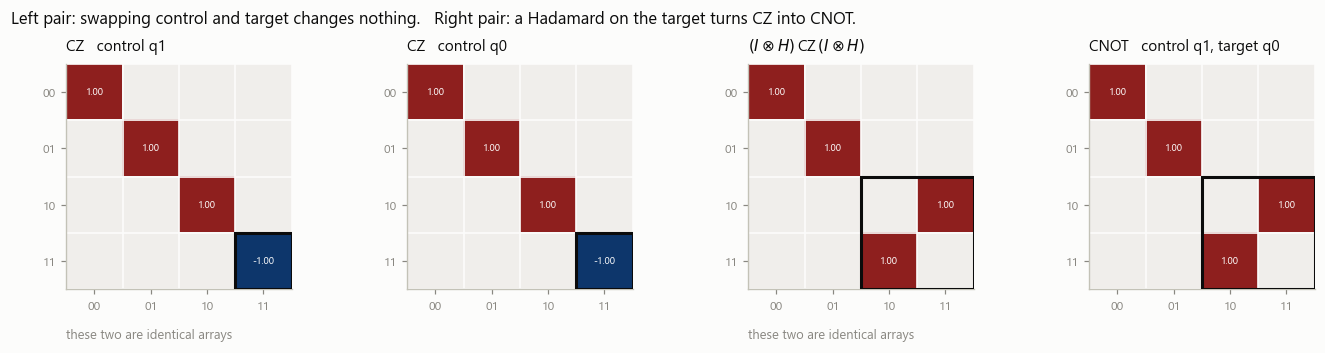

In [8]:
H_on_q0 = op_on(H, 0, 2)                          # this is I (x) H
rebuilt = H_on_q0 @ CZ @ H_on_q0

print("CZ(control=q1) == CZ(control=q0) ?", np.allclose(CZ, CZ_REV))
print("(I(x)H) CZ (I(x)H) == CNOT(c=q1,t=q0) ?",
      np.allclose(rebuilt, CNOT_10))
print("\nmax |difference| :", np.max(np.abs(rebuilt - CNOT_10)))

fig, axes = plt.subplots(1, 4, figsize=(12.4, 3.2))
for ax, (name, M) in zip(axes, [
        ("CZ   control q1", CZ),
        ("CZ   control q0", CZ_REV),
        (r"$(I \otimes H)\,$CZ$\,(I \otimes H)$", rebuilt),
        ("CNOT   control q1, target q0", CNOT_10)]):
    grid.matrix(ax, M, part="re", cbar=False, title=name)
    if name.startswith("CZ"):
        outline(ax, [3], [3], color=style.INK, lw=2.0)
    else:
        outline(ax, [2, 3], [2, 3], color=style.INK, lw=2.0)
axes[0].text(0.0, -0.22, "these two are identical arrays", fontsize=8.5,
             color=style.MUTED, transform=axes[0].transAxes)
axes[2].text(0.0, -0.22, "these two are identical arrays", fontsize=8.5,
             color=style.MUTED, transform=axes[2].transAxes)
fig.suptitle("Left pair: swapping control and target changes nothing.   "
             "Right pair: a Hadamard on the target turns CZ into CNOT.",
             x=0.005, ha="left", fontsize=11)
plt.show()

The first claim deserves a moment of discomfort. A circuit diagram draws CNOT
with a filled dot on one wire and a $\oplus$ on the other, and every intuition
you have says information flows dot $\to$ plus. But CNOT is one Hadamard away
from a gate that is *provably* symmetric — and a Hadamard on the target cannot
create or destroy a causal arrow. So the arrow was never there.

What *is* true is that in the computational basis the gate looks asymmetric. In
the $|{\pm}\rangle$ basis it looks asymmetric the other way: CNOT with control
$q_1$ acts on $|{\pm}\rangle$ states as a CNOT with control $q_0$. That is phase
kickback, and A10 builds phase estimation on top of it.

## Figure 6 — SWAP = 3 CNOTs

There is no SWAP instruction on real hardware. There is a CNOT (or something
CNOT-like), and SWAP is compiled into three of them, alternating direction:

$$\mathrm{SWAP} = \mathrm{CNOT}_{0\to1}\ \mathrm{CNOT}_{1\to0}\ \mathrm{CNOT}_{0\to1}.$$

Since all four gates here are permutations, we can watch the composition happen.
The figure traces where each of the four basis states sits after each CNOT — a
wiring diagram of the permutation. Follow a coloured line left to right; the two
middle lines cross over and stay crossed, the outer two return home.

This is not a curiosity. It is why the "honest limits" section below matters: on
a chip where two qubits are not neighbours, every logical CNOT between them costs
a chain of these three-CNOT SWAPs, and the error budget goes with it.

CNOT_01 . CNOT_10 . CNOT_01 == SWAP ? True


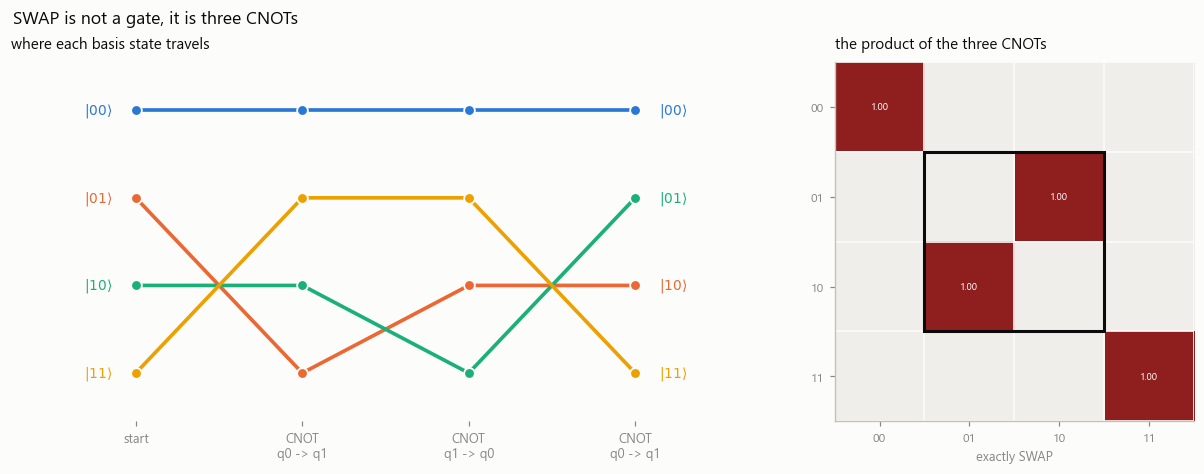

In [9]:
A = CNOT_01               # control q0 -> target q1
B = CNOT_10               # control q1 -> target q0
swap_from_cnots = A @ B @ A      # rightmost matrix acts first

print("CNOT_01 . CNOT_10 . CNOT_01 == SWAP ?",
      np.allclose(swap_from_cnots, SWAP))

steps = [permutation_of(A), permutation_of(B), permutation_of(A)]
step_names = ["start", "CNOT\nq0 -> q1", "CNOT\nq1 -> q0", "CNOT\nq0 -> q1"]

fig = plt.figure(figsize=(11.4, 4.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1])

ax = fig.add_subplot(gs[0, 0])
for start in range(4):
    track, cur = [start], start
    for perm in steps:
        cur = perm[cur]
        track.append(cur)
    ys = [3 - t for t in track]            # index 0 at the top
    ax.plot(range(4), ys, color=style.CAT[start], lw=2.4, marker="o", ms=7,
            markeredgecolor=style.SURFACE, markeredgewidth=1.2, zorder=3,
            solid_capstyle="round")
    ax.text(-0.14, 3 - start, grid.ket(label(start, 2)), ha="right",
            va="center", fontsize=9, color=style.CAT[start])
    ax.text(3.14, 3 - track[-1], grid.ket(label(track[-1], 2)), ha="left",
            va="center", fontsize=9, color=style.CAT[start])
ax.set_xticks(range(4))
ax.set_xticklabels(step_names, fontsize=8.5)
ax.set_yticks([])
ax.set_xlim(-0.75, 3.75)
ax.set_ylim(-0.55, 3.55)
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_title("where each basis state travels", loc="left", fontsize=10)

ax2 = fig.add_subplot(gs[0, 1])
grid.matrix(ax2, swap_from_cnots, part="re", cbar=False,
            title="the product of the three CNOTs")
outline(ax2, [1, 2], [1, 2], color=style.INK, lw=2.0)
ax2.set_xlabel("exactly SWAP", fontsize=8.5, color=style.MUTED)
fig.suptitle("SWAP is not a gate, it is three CNOTs", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

## Figure 7 — the punchline: two-qubit gates make entanglement, one-qubit gates cannot

This is the reason two-qubit gates exist.

**The test.** Write a two-qubit state's four amplitudes as a $2\times2$ matrix,
with the row chosen by qubit 1 and the column by qubit 0:

$$M = \begin{pmatrix} \psi_{00} & \psi_{01} \\ \psi_{10} & \psi_{11}\end{pmatrix},
\qquad M_{b_1 b_0} = \psi_{\,b_1 b_0}.$$

Then $|\psi\rangle$ is a **product state** — the two qubits have independent,
separate descriptions — precisely when $M$ has **rank 1**, because
$|a\rangle\otimes|b\rangle$ reshapes to the outer product $a\,b^{\mathsf{T}}$,
and outer products are exactly the rank-1 matrices. Rank 2 means **entangled**.
The singular values of $M$ are the *Schmidt coefficients*; how many are non-zero
is the *Schmidt rank*.

**The demonstration.** Put qubit 0 in $|+\rangle$ and leave qubit 1 in
$|0\rangle$ — a product state, Schmidt rank 1. (Careful with the label: with
qubit 0 rightmost this state prints as $|0{+}\rangle$, though a big-endian
textbook would write the same thing as $|{+}0\rangle$.) Apply CNOT with control
qubit 0. Out comes the Bell state $\tfrac{1}{\sqrt2}(|00\rangle + |11\rangle)$,
Schmidt rank 2.

**The proof that single-qubit gates can't.** A single-qubit gate on qubit 1 is
$A \otimes I$ and one on qubit 0 is $I \otimes B$; any product of them is
$A \otimes B$, and in this reshaping

$$(A \otimes B)\,|\psi\rangle \ \longleftrightarrow\ A\,M\,B^{\mathsf{T}}.$$

$A$ and $B^{\mathsf T}$ are invertible, so **the rank of $M$ cannot change**.
Rank is a local-unitary invariant. Entanglement is not something you can talk a
qubit into individually; it has to be built by a gate that touches both.

The bottom panel throws 400 random single-qubit gate pairs at each state and
watches the second Schmidt coefficient refuse to move.

product state: [0.7071 0.7071 0.     0.    ]  Schmidt: [1. 0.]
Bell state   : [0.7071 0.     0.     0.7071]  Schmidt: [0.7071 0.7071]


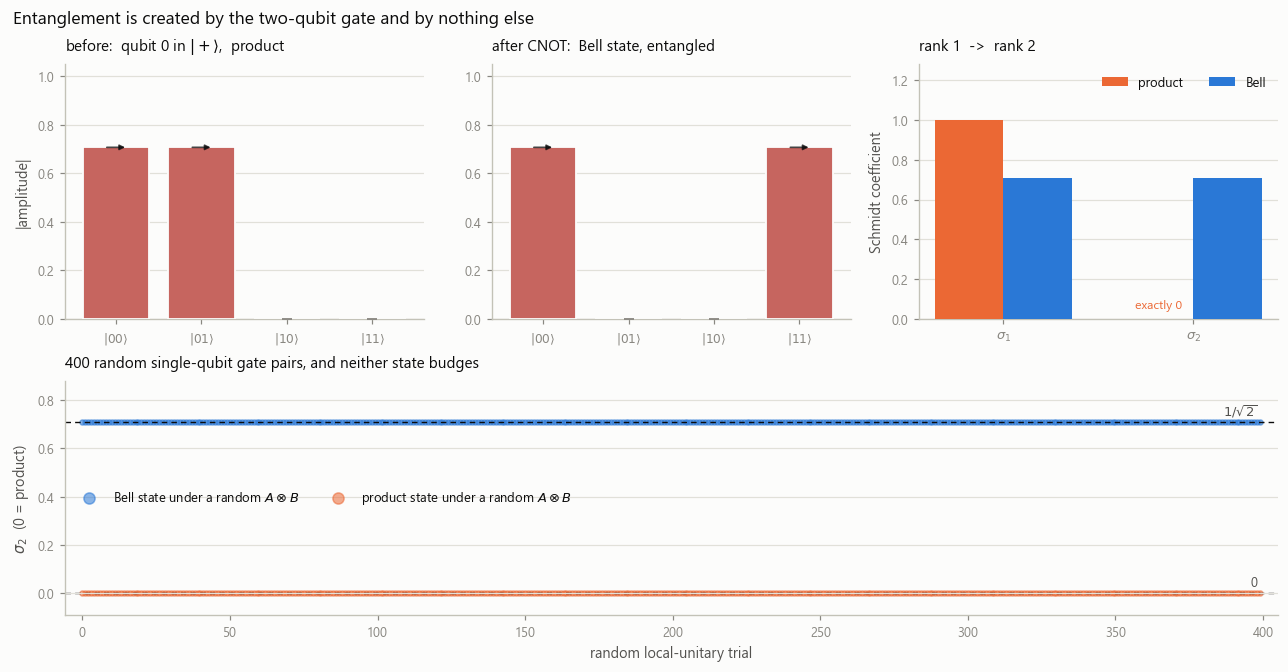


largest sigma_2 seen on the product state: 3.53e-16
sigma_2 on the Bell state: min 0.707107  max 0.707107   (1/sqrt(2) = 0.707107)


In [10]:
def schmidt(vec):
    """Singular values of the 2x2 reshaping. Rows = qubit 1, cols = qubit 0."""
    return np.linalg.svd(np.asarray(vec).reshape(2, 2), compute_uv=False)


def haar_u2(rng):
    """Haar-random 2x2 unitary: QR of a complex Gaussian, phases fixed."""
    z = (rng.normal(size=(2, 2)) + 1j * rng.normal(size=(2, 2))) / np.sqrt(2)
    q, r = np.linalg.qr(z)
    return q @ np.diag(np.diag(r) / np.abs(np.diag(r)))


ket00 = np.zeros(4, dtype=complex); ket00[0] = 1.0
product = op_on(H, 0, 2) @ ket00          # qubit 0 -> |+>, qubit 1 stays |0>
bell = CNOT_01 @ product

print("product state:", np.round(product.real, 4), " Schmidt:",
      np.round(schmidt(product), 4))
print("Bell state   :", np.round(bell.real, 4), " Schmidt:",
      np.round(schmidt(bell), 4))

N = 400
s2_prod = np.empty(N)
s2_bell = np.empty(N)
for k in range(N):
    local = np.kron(haar_u2(rng), haar_u2(rng))    # A on qubit 1, B on qubit 0
    s2_prod[k] = schmidt(local @ product)[1]
    s2_bell[k] = schmidt(local @ bell)[1]

fig = plt.figure(figsize=(11.6, 6.0))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.92])

axa = fig.add_subplot(gs[0, 0])
grid.amp_bars(axa, product, ylim=1.05)
axa.set_title("before:  qubit 0 in " + grid.ket("+") + ",  product",
              loc="left", fontsize=10)

axb = fig.add_subplot(gs[0, 1])
grid.amp_bars(axb, bell, ylim=1.05)
axb.set_ylabel("")
axb.set_title("after CNOT:  Bell state, entangled", loc="left", fontsize=10)

axc = fig.add_subplot(gs[0, 2])
w = 0.36
sp, sb = schmidt(product), schmidt(bell)
axc.bar(np.arange(2) - w / 2, sp, width=w, color=style.ORANGE, label="product",
        zorder=3)
axc.bar(np.arange(2) + w / 2, sb, width=w, color=style.BLUE, label="Bell",
        zorder=3)
axc.set_axisbelow(True)
axc.set_xticks([0, 1])
axc.set_xticklabels([r"$\sigma_1$", r"$\sigma_2$"])
axc.set_ylabel("Schmidt coefficient")
axc.set_ylim(0, 1.28)
axc.legend(loc="upper right", ncols=2)
axc.set_title("rank 1  ->  rank 2", loc="left", fontsize=10)
axc.text(1 - w / 2, 0.055, "exactly 0", ha="center", fontsize=8,
         color=style.ORANGE, zorder=4)

axd = fig.add_subplot(gs[1, :])
axd.scatter(np.arange(N), s2_bell, s=11, color=style.BLUE, alpha=0.55,
            label="Bell state under a random $A \\otimes B$")
axd.scatter(np.arange(N), s2_prod, s=11, color=style.ORANGE, alpha=0.55,
            label="product state under a random $A \\otimes B$")
axd.axhline(1 / np.sqrt(2), color=style.INK, lw=0.9, ls=(0, (4, 3)), zorder=1)
axd.axhline(0.0, color=style.INK, lw=0.9, ls=(0, (4, 3)), zorder=1)
axd.text(N * 0.995, 1 / np.sqrt(2) + 0.03, r"$1/\sqrt{2}$", ha="right",
         fontsize=8.5, color=style.INK_2)
axd.text(N * 0.995, 0.03, "0", ha="right", fontsize=8.5, color=style.INK_2)
axd.set_xlim(-6, N + 5)
axd.set_ylim(-0.09, 0.88)
axd.set_xlabel("random local-unitary trial")
axd.set_ylabel(r"$\sigma_2$  (0 = product)")
axd.legend(loc="center left", ncols=2, markerscale=2.2)
axd.set_title("400 random single-qubit gate pairs, and neither state budges",
              loc="left", fontsize=10)

fig.suptitle("Entanglement is created by the two-qubit gate and by nothing else",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"\nlargest sigma_2 seen on the product state: {s2_prod.max():.2e}")
print(f"sigma_2 on the Bell state: min {s2_bell.min():.6f}  "
      f"max {s2_bell.max():.6f}   (1/sqrt(2) = {1/np.sqrt(2):.6f})")

Two orange dots' worth of numerical noise around $10^{-16}$, and a blue line
pinned to $1/\sqrt2$ across 400 random trials. That is what a conservation law
looks like in a plot.

A useful way to hold this: single-qubit gates move a state *around* its
entanglement class; two-qubit gates move it *between* classes. Any circuit made
only of single-qubit gates, no matter how deep, keeps every qubit's state
separately describable — which is exactly why such a circuit is trivially
simulable on a laptop and offers no advantage whatsoever.

## Deep dive — controlled-anything, and the first sight of phase kickback

*Skip on a first read.*

`controlled(U, control, target, n)` works for any single-qubit $U$ and any pair
of qubits in any register, because it is written in terms of `op_on` rather than
in terms of a hard-coded $4\times4$ layout. Three checks are worth running:

1. It is unitary whenever $U$ is.
2. Its two diagonal blocks (in the basis sorted by the control bit) really are
   $I$ and $U$.
3. If the target starts in an **eigenstate** of $U$, with $U|u\rangle = e^{i\phi}|u\rangle$,
   then the target never changes — and the phase $e^{i\phi}$ appears on the
   *control* instead:

$$\mathrm{CU}\,\big(|{+}\rangle_c \otimes |u\rangle_t\big)
= \tfrac{1}{\sqrt2}\big(|0\rangle + e^{i\phi}|1\rangle\big)_c \otimes |u\rangle_t.$$

This is **phase kickback**: the gate "does nothing" to the target and quietly
writes an answer onto the control. It is the engine of phase estimation (A10),
of Deutsch–Jozsa (A09), and of Shor (C26). Notice too that the output is a
*product* state — a controlled gate does not have to entangle; whether it does
depends entirely on the input.

In [11]:
# 1 + 2: a generic controlled-U, checked against the block form.
for name, U in [("T", T), ("H", H), ("S", S), ("Y", Y)]:
    CU = controlled(U, control=1, target=0)          # control = leftmost label bit
    block = np.block([[np.eye(2), np.zeros((2, 2))],
                      [np.zeros((2, 2)), U]])
    unitary = np.allclose(CU.conj().T @ CU, np.eye(4))
    print(f"controlled-{name:<2}  unitary: {unitary}   "
          f"equals [[I,0],[0,U]]: {np.allclose(CU, block)}")

# A random unitary, to be sure it is not a coincidence of the named gates.
U_rand = haar_u2(rng)
CU_rand = controlled(U_rand, control=1, target=0)
print("\nrandom U: controlled-U unitary?",
      np.allclose(CU_rand.conj().T @ CU_rand, np.eye(4)))

# 3: phase kickback. T has eigenvector |1> with eigenvalue exp(i pi/4).
# kron(a, b) puts `a` on qubit 1 and `b` on qubit 0 (qubit 0 is the LAST factor).
# So: control = qubit 0 in |+>, target = qubit 1 in the eigenstate |1>.
plus = np.array([1, 1], dtype=complex) / np.sqrt(2)
one = np.array([0, 1], dtype=complex)
state = np.kron(one, plus)
CT = controlled(T, control=0, target=1)
out = CT @ state

print("\ninput  ", grid.show_state(state), sep="\n")
print("output ", grid.show_state(out), sep="\n")
kicked = np.angle(out[3] / out[2])      # index 3 = control 1, index 2 = control 0
print(f"\nphase picked up by the control: {kicked/np.pi:.4f} pi "
      f"(expected {1/4:.4f} pi)")
print("target still exactly |1>? ",
      np.allclose(schmidt(out), [1.0, 0.0], atol=1e-12),
      " (Schmidt rank 1 -> still a product state)")

controlled-T   unitary: True   equals [[I,0],[0,U]]: True
controlled-H   unitary: True   equals [[I,0],[0,U]]: True
controlled-S   unitary: True   equals [[I,0],[0,U]]: True
controlled-Y   unitary: True   equals [[I,0],[0,U]]: True

random U: controlled-U unitary? True

input  
  |10>  +0.7071+0.0000j
  |11>  +0.7071+0.0000j
output 
  |10>  +0.7071+0.0000j
  |11>  +0.5000+0.5000j

phase picked up by the control: 0.2500 pi (expected 0.2500 pi)
target still exactly |1>?  True  (Schmidt rank 1 -> still a product state)


## Honest limits

**The matrix view does not scale, at all.** A two-qubit gate is 16 numbers, which
is why this notebook could print them. A gate on a 10-qubit register is a
$1024 \times 1024$ matrix — a million complex numbers, 16 MB — to describe an
operation that, as Figure 2 showed, is usually 99.9% identity. At 20 qubits the
matrix is 17 *terabytes* while the statevector it acts on is 16 MB. Forming the
matrix is the wrong algorithm, and A07 builds a simulator that never does:
it reshapes the statevector and contracts the little $2\times2$ or $4\times4$
block directly onto the axes it touches.

**Real hardware has no all-to-all connectivity.** Every gate in this notebook was
applied to whichever pair of qubits we liked. A superconducting chip only has
two-qubit gates between *physically adjacent* qubits. A CNOT between qubit 0 and
qubit 7 does not exist; the compiler inserts SWAPs to walk one of them over — and
Figure 6 just showed a SWAP is three CNOTs. So a "single" long-range CNOT can
cost a dozen or more physical two-qubit gates, each with roughly 100x the error
rate of a single-qubit gate. Routing is often the dominant cost of a real
circuit, and C30 measures it on a real coupling map.

**The rank test only works for pure states.** Schmidt rank cleanly separates
product from entangled for a *pure* two-qubit state. For mixed states (A12) the
question "is this entangled?" is genuinely harder — rank tells you nothing, and
you need something like the PPT/Peres–Horodecki criterion. Even for pure states,
rank is a yes/no answer: it says the Bell state and a barely-entangled state are
both "rank 2" while the *amount* of entanglement differs enormously. The Schmidt
coefficients themselves carry that, via the entanglement entropy.

**Permutation graphs only draw permutation gates.** Figure 3 is the clearest
picture in this notebook and it cannot show CZ, CRz, iSWAP, or any gate with a
non-trivial phase — and phase is where the interesting quantum behaviour lives.
Every visualization in this repo trades something away; the job is to know what.

**"Controlled" is a basis-dependent name.** Figure 5 and the kickback demo both
made this point. If you carry a mental model where the control is a cause and the
target is an effect, phase estimation will look like magic instead of like
bookkeeping.

## Checkpoint

In [12]:
# 1. Everything we built is unitary.
GATES = {"CNOT_10": CNOT_10, "CNOT_01": CNOT_01, "CZ": CZ, "SWAP": SWAP,
         "iSWAP": ISWAP, "CRz(pi/2)": CRZ, "CCX_12_0": CCX_12_0,
         "CCX_01_2": CCX_01_2}
for name, M in GATES.items():
    d = M.shape[0]
    assert np.allclose(M.conj().T @ M, np.eye(d)), name

# 2. CNOT matches a hand-written truth table, both orientations.
assert np.allclose(CNOT_10, CNOT_10_HAND)
assert np.allclose(CNOT_01, CNOT_01_HAND)
assert np.allclose(CNOT_10, cnot_truth_table(1, 0))
assert np.allclose(CNOT_01, cnot_truth_table(0, 1))

# 3. Little-endian sanity: control q0 must swap indices 1 and 3, not 2 and 3.
assert permutation_of(CNOT_01) == [0, 3, 2, 1]
assert permutation_of(CNOT_10) == [0, 1, 3, 2]

# 4. Every gate here is its own inverse except iSWAP and CRz.
for name in ("CNOT_10", "CNOT_01", "CZ", "SWAP", "CCX_12_0"):
    M = GATES[name]
    assert np.allclose(M @ M, np.eye(M.shape[0])), name
assert not np.allclose(ISWAP @ ISWAP, np.eye(4))

# 5. CZ is symmetric under exchanging control and target.
assert np.allclose(CZ, CZ_REV)
assert np.allclose(CZ, np.diag([1, 1, 1, -1]))
assert np.allclose(CZ, SWAP @ CZ @ SWAP)          # the strong form

# 6. CNOT = (I (x) H) CZ (I (x) H).
assert np.allclose(op_on(H, 0, 2) @ CZ @ op_on(H, 0, 2), CNOT_10)
assert np.allclose(op_on(H, 1, 2) @ CZ @ op_on(H, 1, 2), CNOT_01)

# 7. SWAP = 3 CNOTs, alternating direction.
assert np.allclose(CNOT_01 @ CNOT_10 @ CNOT_01, SWAP)
assert np.allclose(CNOT_10 @ CNOT_01 @ CNOT_10, SWAP)

# 8. Toffoli's truth table: flips the target iff both controls are 1.
for i in range(8):
    b = bits_of(i, 3)
    want = list(b)
    if b[1] == 1 and b[2] == 1:
        want[0] ^= 1
    assert np.isclose(CCX_12_0[index_of(want), i], 1.0)

# 9. Entanglement: a two-qubit gate raises the Schmidt rank...
assert np.isclose(schmidt(product)[1], 0.0, atol=1e-12)
assert np.isclose(schmidt(bell)[1], 1 / np.sqrt(2))

# 10. ...and no product of single-qubit gates ever can (either direction).
for _ in range(200):
    local = np.kron(haar_u2(rng), haar_u2(rng))
    assert np.isclose(schmidt(local @ product)[1], 0.0, atol=1e-10)
    assert np.isclose(schmidt(local @ bell)[1], 1 / np.sqrt(2))

# 11. CZ leaves every probability alone but does change the state.
assert np.allclose(np.abs(CZ @ PLUSPLUS) ** 2, np.abs(PLUSPLUS) ** 2)
assert not np.allclose(CZ @ PLUSPLUS, PLUSPLUS)
assert np.isclose(schmidt(CZ @ PLUSPLUS)[1], 1 / np.sqrt(2))   # and entangles it

# 12. The generic construction agrees with the specific ones.
assert np.allclose(controlled(X, 1, 0), CNOT_10)
assert np.allclose(multi_controlled(X, (1,), 0, 2), CNOT_10)

print("A06 checkpoint passed.")

A06 checkpoint passed.


---

**Next:** [A07 — A Statevector Simulator That Scales](A07_Statevector_Simulator.ipynb).
We have now built gates as matrices twice — and both times noticed that the
matrix is almost entirely identity, and that it grows as $4^n$ while the state it
acts on grows as $2^n$. A07 throws the matrices away and applies gates directly
to the statevector's axes, which is how every real simulator works.